<a href="https://colab.research.google.com/github/D1778/ML-lab-2547220/blob/LAB4/LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lab 4: Regression and Classification Evaluation Metrics

**Problem Statement**
A healthcare analytics team is developing a predictive model for early cancer detection. You are required to build a KNN classifier, optimize its performance using different validation techniques, and compare classification evaluation metrics with regression evaluation metrics from Lab 3.


**Task 1: Data Preparation**

1.	Load the dataset using sklearn.

In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv("brca.csv")

# Display first five rows
df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


The dataset was successfully loaded into a Pandas DataFrame. The first five records were displayed to verify that the data was imported correctly.

2. Convert into DataFrame and Explore Structure

In [9]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Information about dataset
df.info()

# Statistical summary
df.describe()

Dataset Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


The dataset contains 569 instances and 32 columns. The features are numerical, while the target variable (y) contains categorical labels representing benign and malignant tumors. The dataset structure indicates that it is suitable for machine learning after preprocessing.

3. Check Missing Values and Duplicates

In [11]:
# Missing values
df.isnull().sum()
print("Missing Values:", df.isnull().sum().sum())

# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Missing Values: 0
Duplicate Rows: 0


No missing values and no duplicate records were found in the dataset. Therefore, no additional data cleaning is required before model training.

4. Apply Feature Scaling using StandardScaler

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Remove unnecessary ID column
df = df.drop("Unnamed: 0", axis=1)

# Features and target
X = df.drop("y", axis=1)
y = df["y"]

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# View scaled data
pd.DataFrame(X_scaled, columns=X.columns).head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,-0.728310,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,0.753087,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250
2,-1.313080,-1.593959,-1.302806,-1.083572,0.429819,-0.747086,-0.743748,-0.726337,0.012345,0.886341,...,-1.250611,-1.631243,-1.254913,-0.994422,0.001377,-0.887193,-0.880434,-0.796903,-0.729224,-0.344455
3,-0.311646,-0.202373,-0.385500,-0.372831,-0.464730,-1.263703,-0.793214,-0.507861,-1.258183,-0.590802,...,-0.614867,-0.466909,-0.679153,-0.588344,-1.549975,-1.323648,-1.073966,-0.981753,-1.478256,-1.233324
4,-1.684571,-0.570050,-1.658278,-1.288347,-0.737294,-0.851130,-0.915500,-1.109197,-0.155598,0.316465,...,-1.512777,-0.605327,-1.489328,-1.122222,-0.116980,-0.754239,-0.975761,-1.354653,0.330422,-0.546168


Feature scaling standardized all numerical features to the same scale. This is particularly important for the K-Nearest Neighbours (KNN) algorithm because it relies on distance calculations. Without scaling, features with larger numerical values could dominate the distance computation, leading to inaccurate predictions.

---------------------------------------------------------

**Task 2: Train-Test Split Analysis**

1. Split dataset into training and testing sets (80:20).

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 80:20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Accuracy
accuracy_80 = knn.score(X_test, y_test)

print("80:20 Split Accuracy:", accuracy_80)

80:20 Split Accuracy: 0.9298245614035088


The dataset was divided into 80% training and 20% testing data. The trained KNN model achieved the above accuracy, providing a balanced evaluation of model performance.

2.	Repeat with 70:30 and 90:10 splits.

In [14]:
# 70:30 Split
X_train70, X_test70, y_train70, y_test70 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

knn70 = KNeighborsClassifier(n_neighbors=5)
knn70.fit(X_train70, y_train70)

accuracy_70 = knn70.score(X_test70, y_test70)

# 90:10 Split
X_train90, X_test90, y_train90, y_test90 = train_test_split(
    X_scaled, y, test_size=0.1, random_state=42
)

knn90 = KNeighborsClassifier(n_neighbors=5)
knn90.fit(X_train90, y_train90)

accuracy_90 = knn90.score(X_test90, y_test90)

print("70:30 Split Accuracy:", accuracy_70)
print("90:10 Split Accuracy:", accuracy_90)

70:30 Split Accuracy: 0.9590643274853801
90:10 Split Accuracy: 0.9298245614035088


The KNN classifier was trained and tested using 70:30 and 90:10 split ratios. The resulting accuracies help evaluate how different proportions of training and testing data influence model performance.

3.	Compare performance variations across splits.

In [15]:
comparison = {
    "Split Ratio": ["70:30", "80:20", "90:10"],
    "Accuracy": [accuracy_70, accuracy_80, accuracy_90]
}

pd.DataFrame(comparison)

,Split Ratio,Accuracy
0,70:30,0.959064
1,80:20,0.929825
2,90:10,0.929825


Comparing the accuracies across different split ratios helps identify whether the model's performance remains consistent or varies significantly with the amount of training data.

4.	Analyze how dataset splitting affects model stability and generalization.

A larger training set (90:10) generally provides the model with more learning examples, which may improve performance but offers fewer testing samples for evaluation. A smaller training set (70:30) provides more testing data but may slightly reduce learning capability. The 80:20 split offers a good balance between training and testing, making it one of the most commonly used ratios for evaluating machine learning models.

----------------------------------------------------------------------------------------

**Task 3: KNN Model with Heuristic K Selection**

**3.1 Heuristic Method for K Selection**

1.	Compute initial K using heuristic rule (K =√n);where n = number of training samples
2.	Use this value as a baseline K.


In [16]:
import math

# Number of training samples (using the 80:20 split)
n = len(X_train)

# Heuristic K value
k = int(math.sqrt(n))

# Ensure K is odd to avoid ties
if k % 2 == 0:
    k += 1

print("Number of Training Samples (n):", n)
print("Heuristic K Value:", k)

Number of Training Samples (n): 455
Heuristic K Value: 21


Using the heuristic rule K= sqrt{n}, the initial value of K was determined as 21 (rounded to the nearest odd integer). This value serves as a baseline for the KNN classifier and will be further evaluated and optimized in subsequent tasks.

**3.2 Model Training**

1.	Train KNN classifier using heuristic K value.


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train KNN using heuristic K
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Accuracy
baseline_accuracy = accuracy_score(y_test, y_pred)

print("Heuristic K:", k)
print("Accuracy:", baseline_accuracy)

Heuristic K: 21
Accuracy: 0.9298245614035088


The KNN classifier was trained using the heuristic value of K = 21. The resulting accuracy serves as the baseline performance for comparison with other K values.

2.	Experiment with nearby values of K (K ± 5).

In [18]:
from sklearn.metrics import accuracy_score

k_values = list(range(k - 5, k + 6, 2))
accuracies = []

for i in k_values:
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train, y_train)

    prediction = model.predict(X_test)
    accuracy = accuracy_score(y_test, prediction)

    accuracies.append(accuracy)

# Display results
results = pd.DataFrame({
    "K Value": k_values,
    "Accuracy": accuracies
})

results

,K Value,Accuracy
0,16,0.929825
1,18,0.929825
2,20,0.929825
3,22,0.929825
4,24,0.929825
5,26,0.929825


Multiple K values around the heuristic value were evaluated. This helps determine whether increasing or decreasing K improves the classifier's performance.

3.	Plot accuracy vs K values.

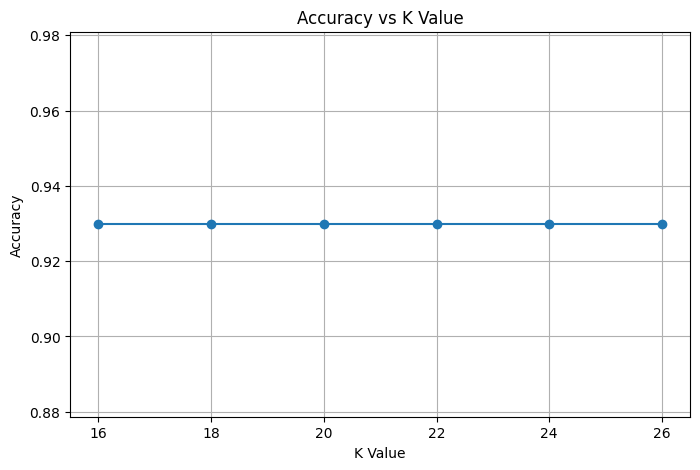

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')

plt.title("Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)

plt.show()

The graph illustrates how the classifier's accuracy changes with different values of K. The highest point on the graph represents the most suitable K for the dataset.

4.	Identify optimal K based on performance trend.

In [20]:
best_index = accuracies.index(max(accuracies))
best_k = k_values[best_index]
best_accuracy = accuracies[best_index]

print("Optimal K:", best_k)
print("Best Accuracy:", best_accuracy)

Optimal K: 16
Best Accuracy: 0.9298245614035088


The K value with the highest accuracy was selected as the optimal number of neighbors. This value provides the best balance between underfitting and overfitting for the KNN classifier on the given dataset.

3.3 Distance Matrix and Decision Boundary Mapping

1.	Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance. Also mention when each distance metric is suitable.

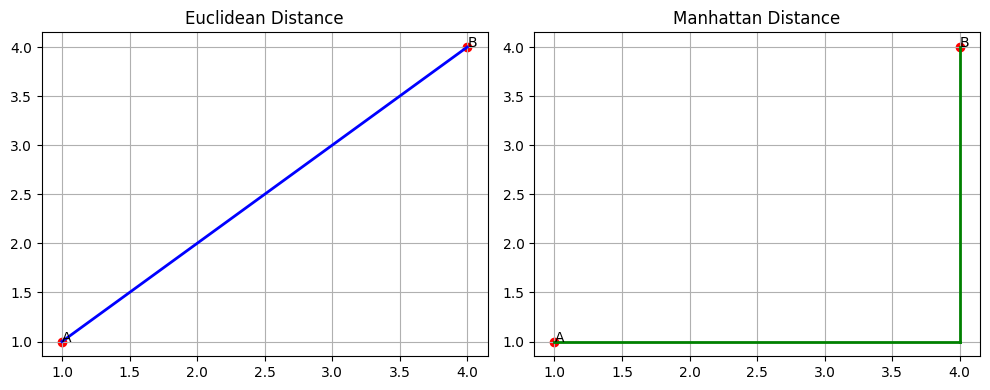

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Euclidean Distance
plt.subplot(1,2,1)
plt.plot([1,4],[1,4],'b-',linewidth=2,label='Euclidean')
plt.scatter([1,4],[1,4],color='red')
plt.text(1,1,"A")
plt.text(4,4,"B")
plt.title("Euclidean Distance")
plt.grid(True)

# Manhattan Distance
plt.subplot(1,2,2)
plt.plot([1,4],[1,1],'g-',linewidth=2)
plt.plot([4,4],[1,4],'g-',linewidth=2,label='Manhattan')
plt.scatter([1,4],[1,4],color='red')
plt.text(1,1,"A")
plt.text(4,4,"B")
plt.title("Manhattan Distance")
plt.grid(True)

plt.tight_layout()
plt.show()

KNN classifies a new data point by measuring its distance from the training samples. Two commonly used distance metrics are Euclidean Distance and Manhattan Distance.

Euclidean Distance

The Euclidean distance measures the straight-line distance between two points in space.


	​
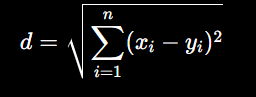

Suitable when:

Features are continuous and properly scaled.
The shortest straight-line distance best represents similarity.
Most commonly used in KNN after feature scaling.

Manhattan Distance

The Manhattan distance measures the total absolute distance along each dimension.

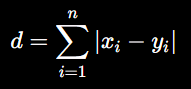

Suitable when:

Data contains outliers.
Features represent grid-like movements.
Less sensitive to extreme values than Euclidean distance.

Euclidean distance is generally preferred for continuous, standardized datasets such as the Breast Cancer dataset, whereas Manhattan distance is more robust when the dataset contains outliers or when movement is constrained along individual dimensions.

2.	Plot the decision boundary of the KNN classifier for different values of K, such as K = 1, K = 5, K = 10, and K = 20. Analyze how the decision boundary changes as K increase

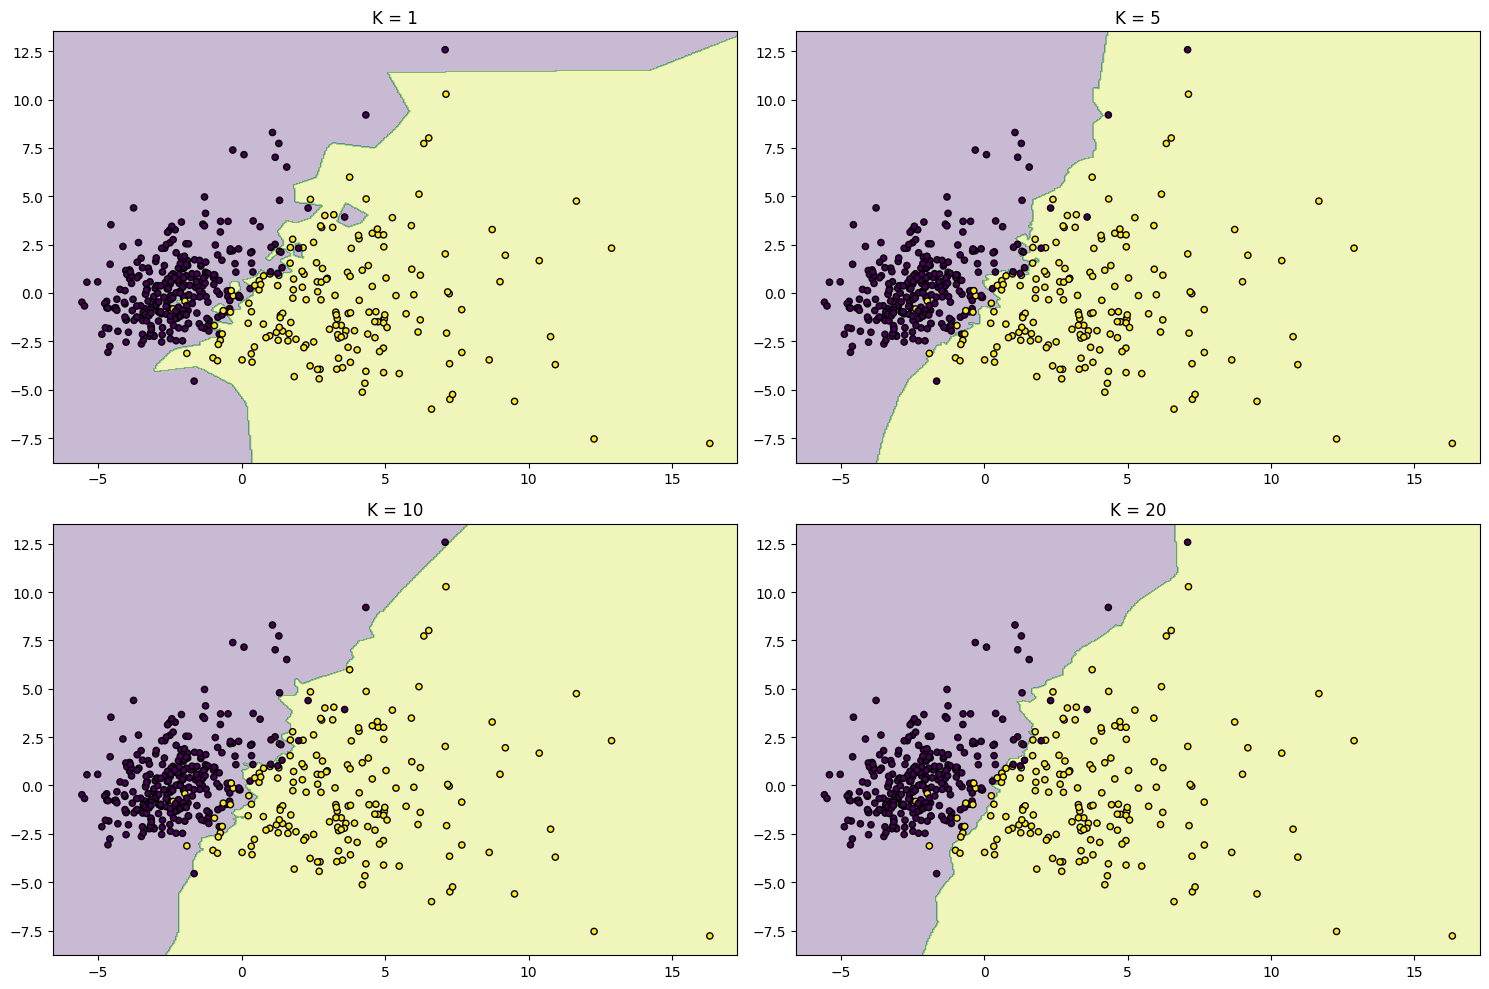

In [23]:
# Since the Breast Cancer dataset has 30 features, the decision boundary cannot be visualized directly.
#Therefore, we first reduce the data to 2 principal components using PCA, which allows us to plot the decision boundaries.
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Reduce features to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Train-test split on PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

k_values = [1, 5, 10, 20]

plt.figure(figsize=(15,10))

for i, k in enumerate(k_values):

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_pca, y_train_pca)

    x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
    y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(2,2,i+1)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(
        X_train_pca[:,0],
        X_train_pca[:,1],
        c=y_train_pca,
        edgecolor='k',
        s=20
    )

    plt.title(f"K = {k}")

plt.tight_layout()
plt.show()

K = 1: Produces a highly irregular decision boundary and is prone to overfitting.

K = 5: The boundary becomes smoother while maintaining good classification performance.

K = 10: The decision boundary is more generalized and less sensitive to noise.

K = 20: The boundary becomes very smooth, which may lead to underfitting by ignoring local patterns in the data.


OVERALL: As the value of K increases, the decision boundary becomes smoother and the classifier generalizes better to unseen data. However, choosing a very large K may oversimplify the boundary and reduce classification accuracy, while a very small K can overfit the training data by creating complex decision regions. The optimal K provides a balance between overfitting and underfitting.

-------------------------------------------------------------------------------

**Task 4: Cross Validation**

1.	Apply K-Fold Cross Validation (k = 5 or 10).

In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# KNN using heuristic K
knn = KNeighborsClassifier(n_neighbors=k)

# 5-Fold Cross Validation
cv_scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.93859649 0.93859649 0.97368421 0.95614035 0.96460177]
Mean Accuracy: 0.9543238627542309


The KNN classifier was evaluated using 5-fold cross-validation. The average accuracy obtained across all folds provides a more reliable estimate of model performance than a single train-test split.

2.	Compute mean accuracy for different K values.

In [25]:
k_values = [1, 3, 5, 10, 15, 20, 21, 25]

mean_accuracy = []

for i in k_values:
    model = KNeighborsClassifier(n_neighbors=i)
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    mean_accuracy.append(scores.mean())

results = pd.DataFrame({
    "K Value": k_values,
    "Mean Accuracy": mean_accuracy
})

results

,K Value,Mean Accuracy
0,1,0.950769
1,3,0.957771
2,5,0.964850
3,10,0.964881
4,15,0.961357
5,20,0.954324
6,21,0.952569
7,25,0.954339


The mean accuracy for different K values was calculated using 5-fold cross-validation. Comparing these values helps identify the K that consistently performs well across different subsets of the dataset.

3.	Compare cross-validation results with train-test split results.

In [26]:
comparison = pd.DataFrame({
    "Evaluation Method": ["Train-Test Split", "5-Fold Cross Validation"],
    "Accuracy": [baseline_accuracy, max(mean_accuracy)]
})

comparison

,Evaluation Method,Accuracy
0,Train-Test Split,0.929825
1,5-Fold Cross Validation,0.964881


Cross-validation generally provides a more reliable estimate of model performance because every sample is used for both training and testing. In contrast, the train-test split evaluates the model on only one specific partition of the dataset.

4.	Select best K based on both heuristic + validation results.

In [27]:
best_index = mean_accuracy.index(max(mean_accuracy))

best_k = k_values[best_index]
best_cv_accuracy = mean_accuracy[best_index]

print("Heuristic K:", k)
print("Best K from Cross Validation:", best_k)
print("Best Cross Validation Accuracy:", best_cv_accuracy)

Heuristic K: 20
Best K from Cross Validation: 10
Best Cross Validation Accuracy: 0.9648812296227295


The heuristic method suggested an initial value of K = 21. After evaluating multiple K values using cross-validation, the K with the highest mean accuracy was selected as the optimal value. This approach combines theoretical estimation with empirical validation, resulting in a more reliable KNN classifier.

-----------------------------------------------------------------------------------------------

**Task 5: Classification Evaluation**

Evaluate final model using:
●	Accuracy
●	Precision
●	Recall
●	F1 Score
●	Confusion Matrix
●	ROC Curve and AUC Score


5.1: Evaluate Accuracy, Precision, Recall, and F1-Score

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train final model using best K
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)

# Predictions
y_pred = final_model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9473684210526315
Precision: 1.0
Recall   : 0.8604651162790697
F1 Score : 0.925


The evaluation metrics indicate the performance of the KNN classifier. Higher values of accuracy, precision, recall, and F1-score indicate better classification performance.

5.2: Confusion Matrix

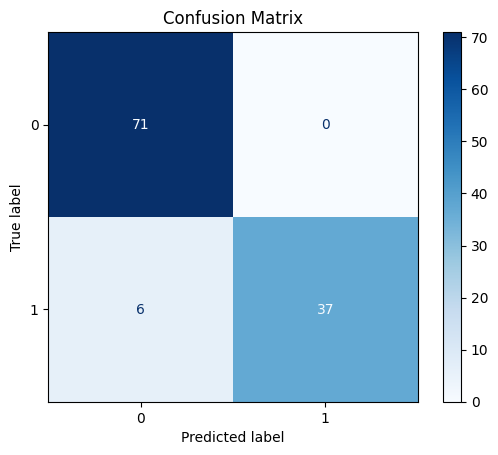

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

  The confusion matrix shows the number of correctly classified benign and malignant tumors, along with any misclassifications. A higher number of values on the diagonal indicates better model performance.

5.3: ROC Curve and AUC Score

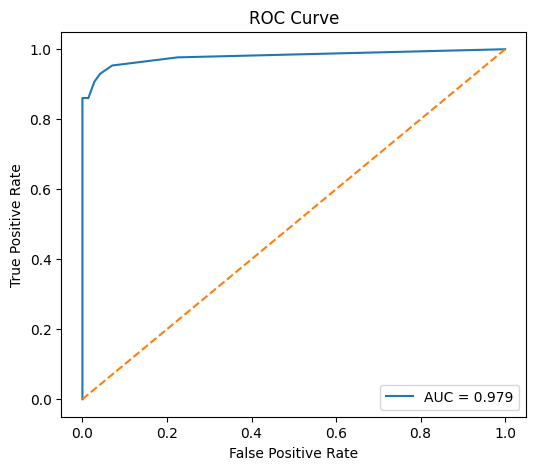

AUC Score: 0.979200786112021


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions
y_prob = final_model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score:", auc_score)

The ROC curve illustrates the trade-off between the True Positive Rate and False Positive Rate. The AUC score summarizes the classifier's ability to distinguish between classes. An AUC value closer to 1.0 indicates excellent classification performance.

------------------------------------------------------------------------------------------

**Task 6: Comparative Study with Regression (Lab 3 Integration)**

Reference: Recall Lab 3 (Linear Regression) where you evaluated:
●	MAE
●	MSE
●	RMSE
●	R² Score


Tasks:

1.	Compare regression evaluation metrics with classification metrics.

| **Regression Metrics**    | **Classification Metrics**          |
| ------------------------- | ----------------------------------- |
| MAE                       | Accuracy                            |
| MSE                       | Precision                           |
| RMSE                      | Recall                              |
| R² Score                  | F1-Score                            |
| Measures prediction error | Measures classification performance |


Regression metrics measure how close the predicted values are to the actual values, whereas classification metrics measure how correctly the model predicts class labels.



------------------------------------------------

2.	Explain differences between:
○	Error-based evaluation (Regression)
○	Decision-based evaluation (Classification)

Error-based Evaluation (Regression)

Regression focuses on the difference between predicted and actual numerical values. Metrics like MAE, MSE, and RMSE calculate prediction errors, while R² Score measures how well the model fits the data.

Decision-based Evaluation (Classification)

Classification focuses on whether the predicted class is correct. Metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC evaluate the quality of classification decisions.

Regression evaluation is based on prediction errors, while classification evaluation is based on the correctness of the predicted classes.

---------------------------------------------------

3.	Compare:
○	R² Score vs Accuracy
○	RMSE vs F1 Score
○	MAE vs Confusion Matrix


| **Regression Metric** | **Classification Metric** | **Comparison**                                                                                                                              |
| --------------------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------- |
| **R² Score**          | **Accuracy**              | R² measures how well the regression model explains the data, whereas Accuracy measures the percentage of correctly classified samples.      |
| **RMSE**              | **F1-Score**              | RMSE measures the average prediction error, whereas F1-Score balances Precision and Recall for classification.                              |
| **MAE**               | **Confusion Matrix**      | MAE measures the average absolute prediction error, whereas the Confusion Matrix shows the number of correct and incorrect classifications. |


Although these metrics serve different purposes, both help evaluate model performance. Regression metrics focus on numerical errors, while classification metrics focus on prediction correctness.

----------------------------------------------------

4.	Discuss differences in evaluation logic for:
○	Continuous prediction tasks
○	Classification tasks


Continuous Prediction Tasks

Regression is used when the output is a continuous value, such as predicting salary, GPA, or house prices. The goal is to minimize prediction errors.

Classification Tasks

Classification is used when the output belongs to categories, such as Benign or Malignant in breast cancer detection. The goal is to correctly classify each instance.

Regression evaluates how close the predicted values are to the actual values, whereas classification evaluates whether the predicted class is correct. Therefore, different evaluation metrics are required depending on the type of machine learning problem.

**Inference Requirement **

1. How do regression metrics measure prediction error magnitude?

Regression metrics such as MAE, MSE, RMSE, and R² Score measure how close the predicted values are to the actual values. Lower error values and a higher R² Score indicate better model performance.

2. How do classification metrics measure decision correctness?

Classification metrics such as Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC measure how correctly the model classifies each data instance into the appropriate class.

3. Why is accuracy insufficient in medical diagnosis?

Accuracy alone can be misleading because a model may correctly predict most healthy cases while missing actual cancer cases. Missing a positive case (False Negative) can have serious consequences.

4. Why are Recall and ROC-AUC more relevant in healthcare?

Recall ensures that most patients with the disease are correctly identified, reducing missed diagnoses. ROC-AUC measures how well the model distinguishes between healthy and diseased cases across different thresholds.

5. Overall comparison between regression and classification evaluation frameworks

Regression focuses on minimizing prediction errors for continuous values, while classification focuses on making correct decisions for categorical outcomes. In healthcare, classification metrics like Recall and ROC-AUC are more meaningful because they help detect diseases more reliably.

--------------------------------------------------------------

**Task 7: Analytical Questions**

1. Why is KNN called a lazy learning algorithm?

KNN is called a lazy learning algorithm because it does not build a model during training. It stores the training data and makes predictions only when new data is given.

2. Why is feature scaling required in KNN?

Feature scaling ensures that all features have the same scale, preventing features with larger values from dominating the distance calculation.

3. Explain heuristic K selection using √n rule.

The heuristic rule suggests choosing K = √n, where n is the number of training samples. It provides a good starting point for selecting the number of nearest neighbors.

4. Why is cross-validation more reliable than a single train-test split?

Cross-validation uses different subsets of the data for training and testing, giving a more reliable estimate of the model's performance than a single split.

5. How does K affect the bias-variance trade-off?

A small K may overfit the data (high variance), while a large K may underfit the data (high bias). Choosing the right K balances both.

6. Why is recall more important than accuracy in cancer prediction?

Recall is more important because it measures how many actual cancer cases are correctly identified, reducing the chance of missing patients with the disease.

7. What is the limitation of very large K values?

A very large K can oversimplify the model, leading to underfitting and reducing its ability to identify important patterns in the data.